# 第11章：自动调优 — 找到最优 Kernel 配置

## 前置知识
- 第01-10章

## 学习目标
- 掌握 `@triton.autotune` 装饰器的使用
- 理解 `triton.Config` 和配置空间
- 学会编写 key 函数和启发式规则
- 使用 `triton.testing.do_bench` 进行性能测量

In [1]:
import torch
import triton
import triton.language as tl

## 11.1 为什么需要自动调优？

GPU kernel 的性能受很多参数影响：

```
BLOCK_M × BLOCK_N × BLOCK_K = 计算密度
num_warps = 线程并行度
num_stages = 流水线深度

最优配置取决于:
├── 矩阵大小 (小矩阵 vs 大矩阵)
├── GPU 架构 (Volta vs Ampere vs Hopper)
├── 内存带宽
├── SM 数量
└── 缓存大小
```

**没有一个配置适合所有场景**，所以我们需要自动调优！

### Triton 的自动调优流程

```
定义配置空间                  运行 benchmark             选最优
┌──────────────┐             ┌──────────────┐          ┌──────────┐
│ Config 1     │─── 实际 ──→│ 测量时间 1   │          │          │
│ Config 2     │─── 运行 ──→│ 测量时间 2   │──选最快─→│ Config 3 │
│ Config 3     │─── 每个 ──→│ 测量时间 3   │          │ = 0.3ms  │
│ Config 4     │─── 配置 ──→│ 测量时间 4   │          │          │
└──────────────┘             └──────────────┘          └──────────┘
```

## 11.2 @triton.autotune 基础

```python
@triton.autotune(
    configs=[                    # 要测试的配置列表
        triton.Config(
            kwargs={'BLOCK_M': 64, 'BLOCK_N': 64, 'BLOCK_K': 32},
            num_warps=4,         # warp 数量 (32线程/warp)
            num_stages=3,        # 流水线阶段数
        ),
        triton.Config(
            kwargs={'BLOCK_M': 128, 'BLOCK_N': 128, 'BLOCK_K': 32},
            num_warps=8,
            num_stages=3,
        ),
        # ... 更多配置
    ],
    key=['M', 'N', 'K'],        # 当这些参数变化时，重新调优
)
@triton.jit
def my_kernel(...):
    ...
```

### 参数说明

| 参数 | 说明 |
|------|------|
| `configs` | `triton.Config` 对象列表，每个定义一组 constexpr 值 |
| `key` | 决定何时重新调优的参数名列表 |
| `num_warps` | 每个 program 使用的 warp 数 (默认 4) |
| `num_stages` | 软件流水线阶段数 (默认 2) |
| `warmup` | 预热运行次数 |
| `rep` | 重复测量次数 |

In [2]:
# 带自动调优的 GEMM kernel
@triton.autotune(
    configs=[
        # 小块: 适合小矩阵或 SM 较多的 GPU
        triton.Config({'BLOCK_M': 32, 'BLOCK_N': 32, 'BLOCK_K': 16}, num_warps=2, num_stages=2),
        triton.Config({'BLOCK_M': 64, 'BLOCK_N': 32, 'BLOCK_K': 16}, num_warps=4, num_stages=2),
        triton.Config({'BLOCK_M': 32, 'BLOCK_N': 64, 'BLOCK_K': 16}, num_warps=4, num_stages=2),
        # 中等块: 通常平衡较好
        triton.Config({'BLOCK_M': 64, 'BLOCK_N': 64, 'BLOCK_K': 32}, num_warps=4, num_stages=3),
        triton.Config({'BLOCK_M': 64, 'BLOCK_N': 64, 'BLOCK_K': 32}, num_warps=8, num_stages=3),
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 64, 'BLOCK_K': 32}, num_warps=4, num_stages=3),
        triton.Config({'BLOCK_M': 64, 'BLOCK_N': 128, 'BLOCK_K': 32}, num_warps=4, num_stages=3),
        # 大块: 适合大矩阵，最大化数据复用
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 128, 'BLOCK_K': 32}, num_warps=8, num_stages=3),
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 128, 'BLOCK_K': 64}, num_warps=8, num_stages=4),
        triton.Config({'BLOCK_M': 256, 'BLOCK_N': 128, 'BLOCK_K': 32}, num_warps=8, num_stages=3),
    ],
    key=['M', 'N', 'K'],  # M/N/K 变化时重新调优
)
@triton.jit
def autotuned_matmul_kernel(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr, BLOCK_K: tl.constexpr,
):
    """自动调优的 GEMM kernel"""
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)
    
    # 累加器
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    
    # K 循环
    for k in range(0, K, BLOCK_K):
        a_offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
        a_offs_k = k + tl.arange(0, BLOCK_K)
        a_ptrs = a_ptr + a_offs_m[:, None] * stride_am + a_offs_k[None, :] * stride_ak
        a_mask = (a_offs_m[:, None] < M) & (a_offs_k[None, :] < K)
        a = tl.load(a_ptrs, mask=a_mask, other=0.0)
        
        b_offs_k = k + tl.arange(0, BLOCK_K)
        b_offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
        b_ptrs = b_ptr + b_offs_k[:, None] * stride_bk + b_offs_n[None, :] * stride_bn
        b_mask = (b_offs_k[:, None] < K) & (b_offs_n[None, :] < N)
        b = tl.load(b_ptrs, mask=b_mask, other=0.0)
        
        acc += tl.dot(a, b)
    
    c_offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    c_offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    c_ptrs = c_ptr + c_offs_m[:, None] * stride_cm + c_offs_n[None, :] * stride_cn
    c_mask = (c_offs_m[:, None] < M) & (c_offs_n[None, :] < N)
    tl.store(c_ptrs, acc.to(tl.float16), mask=c_mask)

In [3]:
def autotuned_matmul(a, b):
    """自动调优的 MatMul 包装"""
    M, K = a.shape
    K, N = b.shape
    c = torch.empty(M, N, device=a.device, dtype=torch.float16)
    
    # 注意: 使用 autotune 时，grid 需要用 lambda
    # 因为 BLOCK_M/BLOCK_N 在调优过程中会变化
    grid = lambda meta: (
        triton.cdiv(M, meta['BLOCK_M']),
        triton.cdiv(N, meta['BLOCK_N']),
    )
    
    autotuned_matmul_kernel[grid](
        a, b, c,
        M, N, K,
        a.stride(0), a.stride(1),
        b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
    )
    return c

# 测试（第一次运行会触发调优，较慢）
print("第一次调用（触发自动调优，可能需要几秒）...")
M, N, K = 512, 512, 256
a = torch.randn(M, K, device='cuda', dtype=torch.float16)
b = torch.randn(K, N, device='cuda', dtype=torch.float16)

c = autotuned_matmul(a, b)
expected = (a.float() @ b.float()).half()
print(f"正确性: {torch.allclose(c, expected, atol=1e-1)}")

# 第二次调用（使用缓存的最优配置，很快）
print("\n第二次调用（使用缓存配置）...")
c2 = autotuned_matmul(a, b)
print(f"正确性: {torch.allclose(c2, expected, atol=1e-1)}")

第一次调用（触发自动调优，可能需要几秒）...
正确性: True

第二次调用（使用缓存配置）...
正确性: True


## 11.3 triton.testing.do_bench — 精确性能测量

```python
ms = triton.testing.do_bench(
    fn,                  # 要测量的函数 (lambda)
    warmup=25,           # 预热次数
    rep=100,             # 测量次数
    quantiles=None,      # 返回分位数 [0.5, 0.2, 0.8]
    return_mode='median', # 'median', 'min', 'max', 'mean'
)
```

**为什么不用 `time.time()`？**
- GPU 操作是异步的，`time.time()` 测的不准
- `do_bench` 使用 CUDA events 精确测量
- 自动处理预热、同步、统计

In [4]:
# 手动 benchmark 不同配置
M, N, K = 2048, 2048, 1024
a = torch.randn(M, K, device='cuda', dtype=torch.float16)
b = torch.randn(K, N, device='cuda', dtype=torch.float16)

# PyTorch 基准
ms_torch = triton.testing.do_bench(lambda: torch.matmul(a, b))
print(f"torch.matmul: {ms_torch:.3f} ms")

# Triton 自动调优版
ms_triton = triton.testing.do_bench(lambda: autotuned_matmul(a, b))
print(f"Triton (autotuned): {ms_triton:.3f} ms")

# 计算 TFLOPS
flops = 2 * M * N * K  # GEMM 的浮点运算数
tflops_torch = flops / ms_torch * 1e-9
tflops_triton = flops / ms_triton * 1e-9
print(f"\ntorch.matmul: {tflops_torch:.1f} TFLOPS")
print(f"Triton:       {tflops_triton:.1f} TFLOPS")
print(f"Triton/Torch: {tflops_triton/tflops_torch*100:.1f}%")

torch.matmul: 0.038 ms
Triton (autotuned): 0.032 ms

torch.matmul: 226.2 TFLOPS
Triton:       265.5 TFLOPS
Triton/Torch: 117.4%


## 11.4 num_warps 和 num_stages 的含义

### num_warps (线程并行度)

```
1 warp = 32 个线程
num_warps=4 → 128 个线程 → 适合中等计算量
num_warps=8 → 256 个线程 → 适合大块计算

选择指南:
  小块 (32×32):   num_warps=2
  中块 (64×64):   num_warps=4
  大块 (128×128): num_warps=8
  超大块 (256×128): num_warps=8-16
```

### num_stages (流水线深度)

```
num_stages=1: 无流水线 (加载 → 计算 → 加载 → 计算)
num_stages=2: 双缓冲 (加载 k+1 的同时计算 k)
num_stages=3: 三缓冲 (更深的流水线，隐藏更多延迟)

代价: 更多的共享内存使用
收益: 更好的计算与内存访问重叠

选择指南:
  Volta/Turing:  num_stages=2-3
  Ampere:        num_stages=3-5 (cp.async 支持)
  Hopper:        num_stages=3-5 (TMA 支持)
```

## 11.5 @triton.testing.perf_report — 生成性能报告

完整的性能基准测试框架：

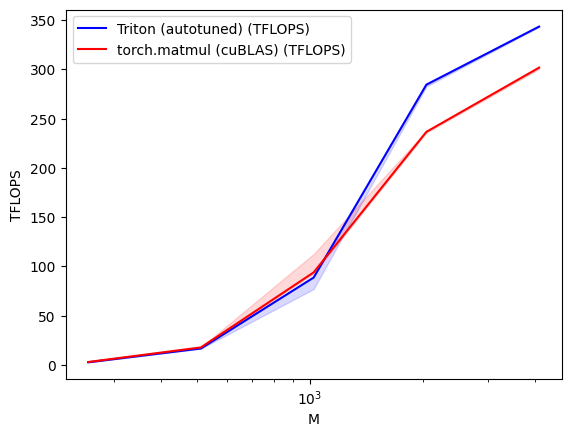

GEMM 性能对比 (FP16, M=N, K=M/2):
        M  Triton (autotuned) (TFLOPS)  torch.matmul (cuBLAS) (TFLOPS)
0   256.0                     2.849391                        3.120762
1   512.0                    16.844594                       17.924376
2  1024.0                    88.768339                       93.990003
3  2048.0                   284.359585                      236.507004
4  4096.0                   343.267839                      301.612864


In [5]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['M'],           # x 轴变量
        x_vals=[256, 512, 1024, 2048, 4096],
        x_log=True,
        line_arg='provider',     # 不同曲线
        line_vals=['triton', 'torch'],
        line_names=['Triton (autotuned)', 'torch.matmul (cuBLAS)'],
        styles=[('blue', '-'), ('red', '-')],
        ylabel='TFLOPS',
        plot_name='GEMM 性能对比 (FP16, M=N, K=M/2)',
        args={},
    )
)
def bench_matmul(M, provider):
    N, K = M, M // 2
    a = torch.randn(M, K, device='cuda', dtype=torch.float16)
    b = torch.randn(K, N, device='cuda', dtype=torch.float16)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: autotuned_matmul(a, b), quantiles=quantiles
        )
    else:
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: torch.matmul(a, b), quantiles=quantiles
        )
    flops = 2 * M * N * K
    tflops = lambda ms: flops / ms * 1e-9
    return tflops(ms), tflops(max_ms), tflops(min_ms)

bench_matmul.run(print_data=True, show_plots=True)

## Part 2 总结

恭喜完成中级部分！你现在掌握了：

```
第07章: Softmax           → 归约 + 数学函数 + 在线算法
第08章: 朴素 MatMul        → GEMM 基础 + tl.dot
第09章: 分块 MatMul        → Tiling + 数据复用
第10章: 算子融合           → MatMul+Bias+Act, LayerNorm
第11章: 自动调优           → @autotune, Config, 性能测量
```

### 下一步: Part 3 — GEMM 终极优化

我们将把 CUDA HGEMM 项目的每一级优化翻译成 Triton:
- 共享内存显式控制
- 内存 Swizzle
- 软件流水线
- Split-K 并行
- Tensor Core 深入
- 终极优化 GEMM

## 练习

1. 给 LayerNorm kernel 加上自动调优，调优 BLOCK_N
2. 为不同矩阵形状（方阵 vs 扁平矩阵 vs 高瘦矩阵）测试最优配置
3. 实现自定义 benchmark: 测量不同 num_stages 对 GEMM 的影响